# Research Question 2 (RQ2)
Is each indicator distinct from all other indicators? In order to evaluate this, we conduct Pearson correlation tests. Indicators which are highly correlated are not distinct from one another. Indicators which are not correlated, are distinct from one another.

## Preparation
Steps before RQ2 can be evaluated.

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import pyplot as plt

sns.set_theme(style="ticks", palette="pastel")
sns.set(font='serif')
%matplotlib inline

In [2]:
tags = ["experiment","dimension","population_size","total_iterations","function","metaheuristic","control_parameters","run"]
diversity = ["DRoC Type A","DRoC Type B","ERT Diversity","Critical Diversity"]
fitness = ["FRoC Type A","FRoC Type B","ERT Fitness","Critical Fitness"]
separation = ["SRoC Type A","SRoC Type B","ERT Separation","Critical Separation"]
mobility = ["MRoC Type A","MRoC Type B","ERT Mobility","Critical Mobility"]
STN = ["ntotal*","nbest*","nshared*","best-strength*"]
IN = ["Mean ID","Mean GC","SNID"]
others = ["EXPLORE%","INFEASIBLE%"]

indicators = diversity + fitness + separation + mobility + STN + IN + others
columns = tags + indicators
data = pd.read_csv("./results.csv", names=columns)

metaheuristics = list(np.unique(data['metaheuristic']))
functions = list(np.unique(data['function']))

In [3]:
metaheuristics_short = {
    'GBestPSO': "sPSO",
    'GreedyPSO': "gPSO",
    'Random20PSO': "20PSO",
    'RandomPSO': "iPSO",
    'RingPSO': "rPSO",
    'VonNeumannPSO': "vnPSO"
}
function_pretty = {
    'AttractiveSector': "Attractive Sector",
    'Brown': "Brown",
    'Discus': "Discus",
    'Ellipsoidal': "Ellipsoidal",
    'Elliptic': "Elliptic",
    'Exponential': "Exponential",
    'GeneralizedDropWave': "Drop Wave",
    'GeneralizedEggCrate': "Egg Crate",
    'GeneralizedPrice2': "Price 2",
    'Mishra1': "Mishra 1",
    'NeedleEye': "Needle Eye",
    'Pinter': "Pinter",
    'Qing': "Qing",
    'Rosenbrock': "Rosenbrock",
    'SchwafferN7': "Schwaffer 7",
    'Schwefel_1.2': "Schwefel $1.2$",
    'Step3Function': "Step 3",
    'Weierstrass': "Weierstrass"
}

## Preliminary Data Investigation

We already know from our previous data investigation that we want to drop any rows containing NaNs.

In [4]:
data = data.dropna(inplace=False)
df = data[["function", "metaheuristic"] + indicators]

We also want to know how much variation there is in each underlying distribution. One cannot calculate the correlation between two indicators for a given experiment, if one of the sets of data has only one distinct value. We need to exclude any such indicator from this research question.


To calculate the variation, we can check the number of distinct values in each underlying distribution.

In [5]:
distinct_values = df.groupby(["function", "metaheuristic"]).nunique()
distinct_values = distinct_values.reset_index(inplace=False)
distinct_values

,function,metaheuristic,DRoC Type A,DRoC Type B,ERT Diversity,Critical Diversity,FRoC Type A,FRoC Type B,ERT Fitness,Critical Fitness,...,Critical Mobility,ntotal*,nbest*,nshared*,best-strength*,Mean ID,Mean GC,SNID,EXPLORE%,INFEASIBLE%
0,AttractiveSector,GBestPSO,30,30,30,30,30,30,30,30,...,30,30,14,26,30,30,30,29,30,30
1,AttractiveSector,GreedyPSO,30,30,30,30,30,30,30,30,...,30,30,19,27,25,30,30,30,30,30
2,AttractiveSector,Random20PSO,30,30,30,30,30,30,30,30,...,30,29,17,26,30,30,28,30,30,30
3,AttractiveSector,RandomPSO,30,30,30,30,30,30,30,30,...,30,13,1,9,1,30,30,30,30,30
4,AttractiveSector,RingPSO,30,30,30,30,30,30,30,30,...,30,30,16,30,30,16,24,29,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,Weierstrass,GreedyPSO,30,30,30,30,30,30,30,30,...,30,30,14,27,21,30,30,30,30,30
104,Weierstrass,Random20PSO,30,30,30,30,30,30,30,30,...,30,30,20,28,30,30,30,30,30,30
105,Weierstrass,RandomPSO,30,30,30,30,30,30,30,30,...,30,13,1,13,1,30,30,30,30,30
106,Weierstrass,RingPSO,30,30,30,30,30,30,30,30,...,30,30,20,28,30,16,27,30,30,30


Most underlying distributions have a good degree of variation. We are only interested in those that have very little variation. To filter to only those,
 we can check how often an indicator has only one distinct value for a given metaheuristic and function.

In [6]:
percentage_non_distinct_all = pd.DataFrame(columns=['Indicator', 'Percentage'])
for indicator in indicators:
    value_count = distinct_values[indicator].value_counts()
    if 1 in value_count:
        percent = value_count[1] / (len(distinct_values)) * 100
    else:
        percent = 0
    percentage_non_distinct_all.loc[len(percentage_non_distinct_all.index)] = [indicator, percent]
percentage_non_distinct_all[percentage_non_distinct_all['Percentage'] > 0]

,Indicator,Percentage
17,nbest*,54.629630
19,best-strength*,35.185185


Now we know that the indicators nbest and best_strength must be excluded from this experiment. Given that neither of these indicators performed well in RQ1, it does not negatively affect the outcome of this experiment overall.

In [7]:
df = df.drop(columns=['nbest*', 'best-strength*'], inplace=False)
indicators.remove('nbest*')
indicators.remove('best-strength*')

## Statistical Test: Pearson Correlation Coefficients

We calculate the Pearson correlation coefficient between every indicator for each unique metaheuristic and function.
Given the quantity of data returned, we aggregate our results by displaying the average correlation found between indicators. We also keep the full results in a table for the supplementary material.

In [8]:
table_df = pd.DataFrame(columns=["Indicator","Metaheuristic","Function"] + indicators)

zero_matrix = np.zeros((len(indicators), len(indicators)))
mean_df = pd.DataFrame(zero_matrix, columns=indicators, index=indicators)
count_df = pd.DataFrame(zero_matrix, columns=indicators, index=indicators)
for function in functions:
    function_df = df[df["function"] == function]
    for metaheuristic in metaheuristics:
        correlation_matrix = function_df[function_df["metaheuristic"] == metaheuristic][indicators].corr(method='pearson')
        for indicator in indicators:
            table_df.loc[len(table_df.index)] = [indicator, metaheuristic, function] + list(correlation_matrix[indicator])
        count_df = count_df.mask(cond=correlation_matrix.notna(), other=count_df + 1)
        mean_df = mean_df.mask(cond=correlation_matrix.notna(), other=mean_df + abs(correlation_matrix))
mean_df = mean_df / count_df

Here we see the full results for the supplementary material:

In [9]:
table_df.head()

,Indicator,Metaheuristic,Function,DRoC Type A,DRoC Type B,ERT Diversity,Critical Diversity,FRoC Type A,FRoC Type B,ERT Fitness,...,MRoC Type B,ERT Mobility,Critical Mobility,ntotal*,nshared*,Mean ID,Mean GC,SNID,EXPLORE%,INFEASIBLE%
0,DRoC Type A,GBestPSO,AttractiveSector,1.000000,0.632183,0.885377,-0.645687,-0.080954,-0.245017,-0.082092,...,-0.274027,-0.030533,0.249532,0.401062,0.395185,0.189533,-0.189533,0.084301,0.345590,0.177728
1,DRoC Type B,GBestPSO,AttractiveSector,0.632183,1.000000,0.621194,-0.999732,-0.040958,-0.329429,-0.125423,...,-0.374627,0.084319,0.378609,0.317567,-0.036265,0.223867,-0.223867,0.172262,0.065533,0.127446
2,ERT Diversity,GBestPSO,AttractiveSector,0.885377,0.621194,1.000000,-0.633261,-0.000893,-0.294880,0.058930,...,-0.182991,0.176440,0.156056,0.589766,0.363670,-0.005115,0.005115,0.212692,0.681723,0.082315
3,Critical Diversity,GBestPSO,AttractiveSector,-0.645687,-0.999732,-0.633261,1.000000,0.042160,0.331359,0.123513,...,0.372759,-0.086319,-0.376204,-0.324439,0.026075,-0.224713,0.224713,-0.173123,-0.076587,-0.129104
4,FRoC Type A,GBestPSO,AttractiveSector,-0.080954,-0.040958,-0.000893,0.042160,1.000000,0.428365,0.812165,...,0.357226,0.502754,-0.344861,0.003023,0.103250,0.162769,-0.162769,-0.008027,0.081386,-0.002809


and we see the aggregated results:

In [11]:
mean_df.head()

,DRoC Type A,DRoC Type B,ERT Diversity,Critical Diversity,FRoC Type A,FRoC Type B,ERT Fitness,Critical Fitness,SRoC Type A,SRoC Type B,...,MRoC Type B,ERT Mobility,Critical Mobility,ntotal*,nshared*,Mean ID,Mean GC,SNID,EXPLORE%,INFEASIBLE%
DRoC Type A,1.000000,0.342991,0.760995,0.386507,0.221486,0.204567,0.213793,0.208808,0.216395,0.179157,...,0.173424,0.183890,0.183373,0.385192,0.241692,0.142398,0.145497,0.154291,0.416380,0.138569
DRoC Type B,0.342991,1.000000,0.396152,0.859924,0.165050,0.206400,0.189337,0.187288,0.152369,0.204774,...,0.173657,0.170916,0.176462,0.226667,0.300316,0.158359,0.147338,0.179427,0.232274,0.154985
ERT Diversity,0.760995,0.396152,1.000000,0.394861,0.188330,0.227176,0.189560,0.236637,0.211452,0.181384,...,0.169413,0.212588,0.172094,0.492789,0.262959,0.161172,0.153109,0.174469,0.551325,0.150739
Critical Diversity,0.386507,0.859924,0.394861,1.000000,0.177068,0.221590,0.202273,0.235061,0.171569,0.196521,...,0.181818,0.170709,0.191471,0.262903,0.321335,0.174427,0.165582,0.201405,0.273377,0.153338
FRoC Type A,0.221486,0.165050,0.188330,0.177068,1.000000,0.267415,0.770797,0.283185,0.237027,0.171139,...,0.166187,0.218301,0.176972,0.199611,0.181103,0.192499,0.189922,0.182724,0.203180,0.154622


## Paper Visualisation

For the paper, we will illustrate the mean PCC value between each pair of indicators in a  heatmap.

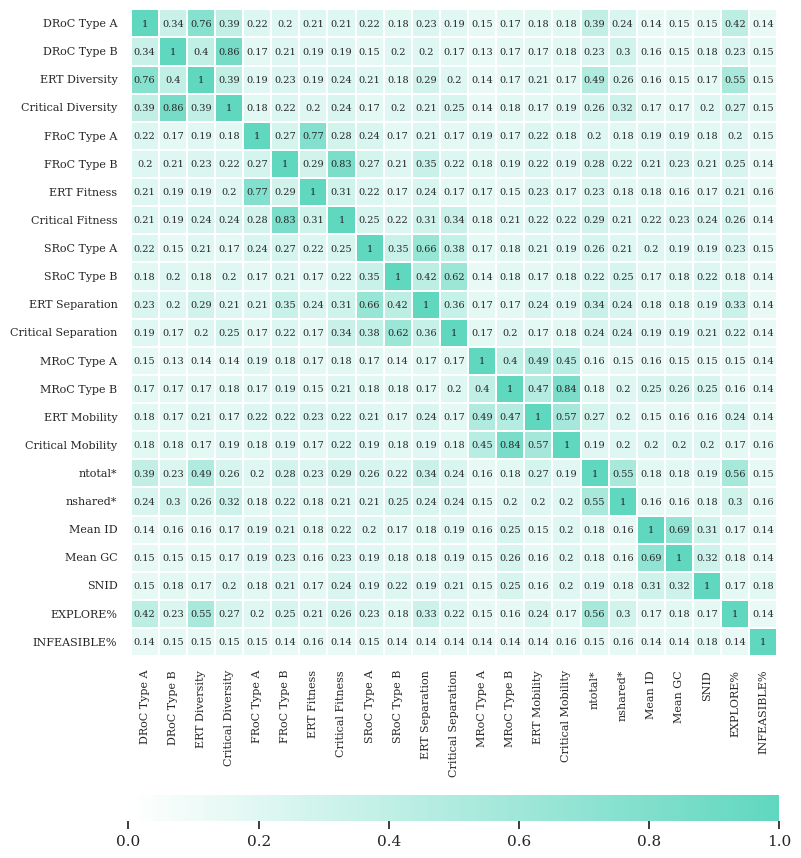

In [24]:
turquoise = "#60D7BF"
white = "#FFFFFF"
cmap = LinearSegmentedColormap.from_list("custom_gradient", [white, turquoise])

plt.figure(figsize=(12,12))
g = sns.heatmap(mean_df.round(2), vmin=0, vmax=1, cmap=cmap,
              square=True, linewidths=0.1, cbar=True, cbar_kws={'shrink': 0.7, "location": "bottom", "aspect": 25},
              annot=True, annot_kws={"fontsize":7}, fmt='.2g',
              xticklabels=1, yticklabels=1) 

g.set_xticklabels(g.get_xticklabels(), fontsize = 8)
g.set_yticklabels(g.get_yticklabels(), rotation = 0, fontsize = 8)
if not os.path.exists(f"../../plots/IndicatorDistinct/Pearson/"):
    os.makedirs(f"../../plots/IndicatorDistinct/Pearson/")
plt.savefig(f"../../plots/IndicatorDistinct/Pearson/average_correlation.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close('all')

For the supplementary material, we save the results to a file

In [12]:
table_df.to_csv("RQ2_Pearson_results.csv", header=True, index=True)